In [1]:
# aperiodic: uses_preview_data

# Predicting Short-Term Crypto Returns with Market Microstructure
#
There's a market microstructure metric that predicts short-term crypto returns
surprisingly well.
Most quants in this space know which one.

This notebook names it, walks through the methodology, and lets you run the same
analysis
to surface similar signals yourself.
Rolling percentile rank is a simple but effective transformation to transform an
arbitrary time series into a (close to) uniform distribution signal, and can
easily work as-is for simplistic backtests as well.


In [2]:

from __future__ import annotations

import datetime
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from aperiodic import get_derivative_metrics, get_metrics, get_ohlcv


def run_position_backtest(
    timestamps: pd.Series,
    position: np.ndarray,
    forward_return: np.ndarray,
    cost_bps_one_way: float = 0.0,
) -> tuple[pd.DataFrame, dict]:
    position = np.asarray(position, dtype=np.float64)
    forward_return = np.asarray(forward_return, dtype=np.float64)

    gross_pnl = position * forward_return
    turnover = np.abs(np.diff(position, prepend=0.0))
    cost = turnover * cost_bps_one_way / 1e4
    net_pnl = gross_pnl - cost
    equity = np.cumprod(1.0 + net_pnl)

    if equity.size == 0:
        bt_frame = pd.DataFrame({"timestamp": timestamps.to_numpy(), "equity_curve": equity})
        bt_summary = {
            "annualized_sharpe": 0.0,
            "net_return_pct": 0.0,
            "max_drawdown_pct": 0.0,
        }
        return bt_frame, bt_summary

    running_max = np.maximum.accumulate(equity)
    drawdowns = (equity - running_max) / running_max
    max_drawdown_pct = float(np.min(drawdowns)) * 100.0

    bars_per_year = 288 * 365
    mean_ret = float(np.mean(net_pnl))
    std_ret = float(np.std(net_pnl, ddof=1)) if len(net_pnl) > 1 else 1.0
    annualized_sharpe = (
        (mean_ret / std_ret) * np.sqrt(bars_per_year) if std_ret > 0 else 0.0
    )
    net_return_pct = (
        float((equity[-1] / equity[0] - 1.0) * 100.0) if len(equity) > 0 else 0.0
    )

    bt_frame = pd.DataFrame({"timestamp": timestamps.to_numpy(), "equity_curve": equity})
    bt_summary = {
        "annualized_sharpe": float(annualized_sharpe),
        "net_return_pct": net_return_pct,
        "max_drawdown_pct": max_drawdown_pct,
    }
    return bt_frame, bt_summary

SYMBOL = "perpetual-BTC-USDT:USDT"
EXCHANGE = "binance-futures"
INTERVAL = "5m"
TIMESTAMP = "exchange"  # local timestamp or "true"

START_DATE = datetime.date(2025, 5, 1)
END_DATE = datetime.date(2025, 5, 31)

# For demonstration purposes, we'll use only the l2_imbalance metric category.
METRICS = [
    # ("basis", "derivative"),
    # ("funding", "derivative"),
    # ("open_interest", "derivative"),
    # ("flow", "regular"),
    # ("impact", "regular"),
    # ("l1_imbalance", "regular"),
    # ("l1_liquidity", "regular"),
    ("l2_imbalance", "regular"),
    # ("l2_liquidity", "regular"),
    # ("returns", "regular"),
    # ("slippage", "regular"),
    # ("trade_size", "regular"),
    # ("updownticks", "regular"),
    # ("run_structure", "regular"),
    # ("vtwap", "regular"),
    # ("range", "regular"),
]

RANK_WINDOWS = [100, 300, 600, 1200]
COST_BPS = 0.0
# Note: keeping a flat cost assumption here for a simple demo baseline.


API_KEY = "..."  # Set via APERIODIC_API_KEY env var or .env file
if API_KEY == "...":
    API_KEY = os.getenv("APERIODIC_API_KEY", "...")
if API_KEY == "...":
    raise RuntimeError("Set APERIODIC_API_KEY in the environment or in .env.")


def get_numeric_metric_frame(metric: str, kind: str) -> pd.DataFrame | None:
    fetcher = get_derivative_metrics if kind == "derivative" else get_metrics
    raw_df = fetcher(
        api_key=API_KEY,
        metric=metric,
        timestamp=TIMESTAMP,
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        output="pandas",
        show_progress=True,
        preview=True,
    )

    # Ensure it's a pandas DataFrame
    df = raw_df.to_pandas() if hasattr(raw_df, "to_pandas") else pd.DataFrame(raw_df)

    if df.empty or "time" not in df.columns:
        return None

    # Select numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if "time" in numeric_cols:
        numeric_cols.remove("time")

    if not numeric_cols:
        return None

    return df.sort_values("time").drop_duplicates(subset=["time"], keep="last")[
        ["time", *numeric_cols]
    ]


def build_panel() -> tuple[pd.DataFrame, list[str]]:
    raw_ohlcv = get_ohlcv(
        api_key=API_KEY,
        timestamp=TIMESTAMP,
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        output="pandas",
        show_progress=True,
        preview=True,
    )

    if hasattr(raw_ohlcv, "to_pandas"):
        panel = raw_ohlcv.to_pandas()
    else:
        panel = pd.DataFrame(raw_ohlcv)

    panel = panel.sort_values("time")[["time", "close"]]

    for metric, kind in METRICS:
        frame = get_numeric_metric_frame(metric, kind)
        if frame is not None:
            panel = panel.merge(frame, on="time", how="left")

    panel = panel.sort_values("time")
    panel["fwd_ret"] = panel["close"].pct_change().shift(-1)
    panel = panel.dropna(subset=["fwd_ret"])

    feature_cols = [
        col
        for col in panel.columns
        if col not in {"time", "close", "fwd_ret"}
        and pd.api.types.is_numeric_dtype(panel[col])
    ]

    print(f"Panel built: {len(panel)} rows. Found {len(feature_cols)} features.")
    return panel, feature_cols


def make_signal(panel_df: pd.DataFrame, feature: str, window: int) -> np.ndarray:
    rank = panel_df[feature].rolling(window).rank(method="average")
    signal = ((rank - 1.0) / (window - 1)) * 2.0 - 1.0
    return signal.to_numpy().astype(np.float64)


panel, feature_cols = build_panel()

print(f"Rows: {len(panel):,}")
print(f"Features: {feature_cols}")
print(panel.head())

Panel built: 8927 rows. Found 24 features.
Rows: 8,927
Features: ['imbalance_5', 'imbalance_ratio_5', 'bid_ask_ratio_5', 'imbalance_5_avg', 'imbalance_ratio_5_avg', 'bid_ask_ratio_5_avg', 'imbalance_10', 'imbalance_ratio_10', 'bid_ask_ratio_10', 'imbalance_10_avg', 'imbalance_ratio_10_avg', 'bid_ask_ratio_10_avg', 'imbalance_20', 'imbalance_ratio_20', 'bid_ask_ratio_20', 'imbalance_20_avg', 'imbalance_ratio_20_avg', 'bid_ask_ratio_20_avg', 'imbalance_25', 'imbalance_ratio_25', 'bid_ask_ratio_25', 'imbalance_25_avg', 'imbalance_ratio_25_avg', 'bid_ask_ratio_25_avg']
                 time    close  imbalance_5  imbalance_ratio_5  \
0 2025-05-01 00:00:00  94190.3       -4.254          -0.340811   
1 2025-05-01 00:05:00  94257.0        8.667           0.409419   
2 2025-05-01 00:10:00  94223.6       16.598           0.685245   
3 2025-05-01 00:15:00  94187.9       -1.647          -0.075326   
4 2025-05-01 00:20:00  94218.8       -7.416          -0.452085   

   bid_ask_ratio_5  imbalance_5

In [3]:
# Calculate forward returns, information coefficient, and backtest for each
# metric and window combination.
forward_returns = panel["fwd_ret"].to_numpy().astype(np.float64)
results = []

for feature in feature_cols:
    for window in RANK_WINDOWS:
        signal_raw = make_signal(panel, feature, window)
        mask = np.isfinite(signal_raw) & np.isfinite(forward_returns)

        print(f"Testing {feature} | window {window}: {mask.sum()} valid observations")

        fit_corr = float(np.corrcoef(signal_raw[mask], forward_returns[mask])[0, 1])

        direction = 1 if fit_corr >= 0 else -1
        bt_frame, bt_summary = run_position_backtest(
            timestamps=panel.loc[mask, "time"],
            position=np.nan_to_num(
                np.clip(signal_raw[mask] * direction, -1.0, 1.0), nan=0.0
            ),
            forward_return=forward_returns[mask],
            cost_bps_one_way=COST_BPS,
        )

        results.append(
            {
                "feature": feature,
                "window": window,
                "direction": direction,
                "fit_corr": fit_corr,
                "sharpe": bt_summary["annualized_sharpe"],
                "total_return": bt_summary["net_return_pct"],
                "max_drawdown": bt_summary["max_drawdown_pct"],
            }
        )

results_df = pd.DataFrame(results).sort_values("sharpe", ascending=False)
print(results_df)

Testing imbalance_5 | window 100: 8828 valid observations
Testing imbalance_5 | window 300: 8628 valid observations
Testing imbalance_5 | window 600: 8328 valid observations
Testing imbalance_5 | window 1200: 7728 valid observations
Testing imbalance_ratio_5 | window 100: 8828 valid observations
Testing imbalance_ratio_5 | window 300: 8628 valid observations
Testing imbalance_ratio_5 | window 600: 8328 valid observations
Testing imbalance_ratio_5 | window 1200: 7728 valid observations
Testing bid_ask_ratio_5 | window 100: 8828 valid observations
Testing bid_ask_ratio_5 | window 300: 8628 valid observations
Testing bid_ask_ratio_5 | window 600: 8328 valid observations
Testing bid_ask_ratio_5 | window 1200: 7728 valid observations
Testing imbalance_5_avg | window 100: 8828 valid observations
Testing imbalance_5_avg | window 300: 8628 valid observations
Testing imbalance_5_avg | window 600: 8328 valid observations
Testing imbalance_5_avg | window 1200: 7728 valid observations
Testing imba

Testing bid_ask_ratio_10 | window 100: 8828 valid observations
Testing bid_ask_ratio_10 | window 300: 8628 valid observations
Testing bid_ask_ratio_10 | window 600: 8328 valid observations


Testing bid_ask_ratio_10 | window 1200: 7728 valid observations
Testing imbalance_10_avg | window 100: 8828 valid observations
Testing imbalance_10_avg | window 300: 8628 valid observations
Testing imbalance_10_avg | window 600: 8328 valid observations
Testing imbalance_10_avg | window 1200: 7728 valid observations
Testing imbalance_ratio_10_avg | window 100: 8828 valid observations
Testing imbalance_ratio_10_avg | window 300: 8628 valid observations
Testing imbalance_ratio_10_avg | window 600: 8328 valid observations
Testing imbalance_ratio_10_avg | window 1200: 7728 valid observations
Testing bid_ask_ratio_10_avg | window 100: 8828 valid observations
Testing bid_ask_ratio_10_avg | window 300: 8628 valid observations
Testing bid_ask_ratio_10_avg | window 600: 8328 valid observations
Testing bid_ask_ratio_10_avg | window 1200: 7728 valid observations
Testing imbalance_20 | window 100: 8828 valid observations
Testing imbalance_20 | window 300: 8628 valid observations
Testing imbalance_2

Testing imbalance_ratio_20_avg | window 1200: 7728 valid observations
Testing bid_ask_ratio_20_avg | window 100: 8828 valid observations
Testing bid_ask_ratio_20_avg | window 300: 8628 valid observations


Testing bid_ask_ratio_20_avg | window 600: 8328 valid observations
Testing bid_ask_ratio_20_avg | window 1200: 7728 valid observations
Testing imbalance_25 | window 100: 8828 valid observations
Testing imbalance_25 | window 300: 8628 valid observations
Testing imbalance_25 | window 600: 8328 valid observations
Testing imbalance_25 | window 1200: 7728 valid observations
Testing imbalance_ratio_25 | window 100: 8828 valid observations
Testing imbalance_ratio_25 | window 300: 8628 valid observations
Testing imbalance_ratio_25 | window 600: 8328 valid observations
Testing imbalance_ratio_25 | window 1200: 7728 valid observations
Testing bid_ask_ratio_25 | window 100: 8828 valid observations
Testing bid_ask_ratio_25 | window 300: 8628 valid observations
Testing bid_ask_ratio_25 | window 600: 8328 valid observations
Testing bid_ask_ratio_25 | window 1200: 7728 valid observations
Testing imbalance_25_avg | window 100: 8828 valid observations
Testing imbalance_25_avg | window 300: 8628 valid o

## Microstructure Takeaways

Note that all of the backtests here are net of transaction costs.

- The metric presented here has high turnover and is most predictive on lower timeframes.
- Market microstructure metrics can be used to enhance directional strategies
  and extend existing signals.
- They can also act as regime filters to help decide when broader
  trend-following ideas are more or less effective.

Best Strategy found:
{'feature': 'imbalance_ratio_5', 'window': 600, 'direction': 1, 'fit_corr': 0.05538312768976763, 'sharpe': 17.420114026878725, 'total_return': 35.91696174883696, 'max_drawdown': -2.318995717954696}


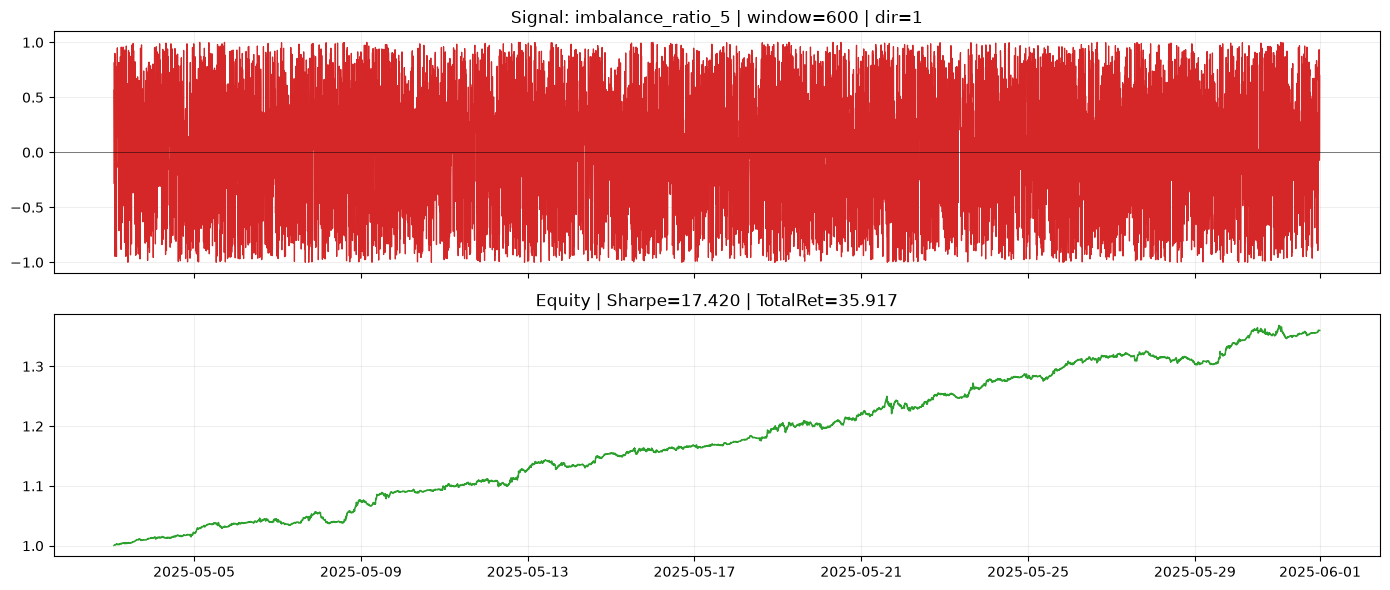

In [4]:
best = results_df.iloc[0].to_dict()
best_feature = str(best["feature"])
best_window = int(best["window"])
best_direction = int(best["direction"])

signal = make_signal(panel, best_feature, best_window) * best_direction
mask = np.isfinite(signal) & np.isfinite(forward_returns)
bt_frame, bt_summary = run_position_backtest(
    timestamps=panel.loc[mask, "time"],
    position=np.nan_to_num(np.clip(signal[mask], -1.0, 1.0), nan=0.0),
    forward_return=forward_returns[mask],
    cost_bps_one_way=COST_BPS,
)
equity = bt_frame["equity_curve"]

print("Best Strategy found:")
print(best)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(panel["time"], signal, linewidth=0.9, color="tab:red")
axes[0].axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
axes[0].set_title(
    f"Signal: {best_feature} | window={best_window} | dir={best_direction}"
)
axes[0].grid(alpha=0.2)

axes[1].plot(bt_frame["timestamp"], equity, linewidth=1.1, color="tab:green")
axes[1].set_title(
    f"Equity | Sharpe={best['sharpe']:.3f} | TotalRet={best['total_return']:.3f}"
)
axes[1].grid(alpha=0.2)

fig.tight_layout()
plt.show()

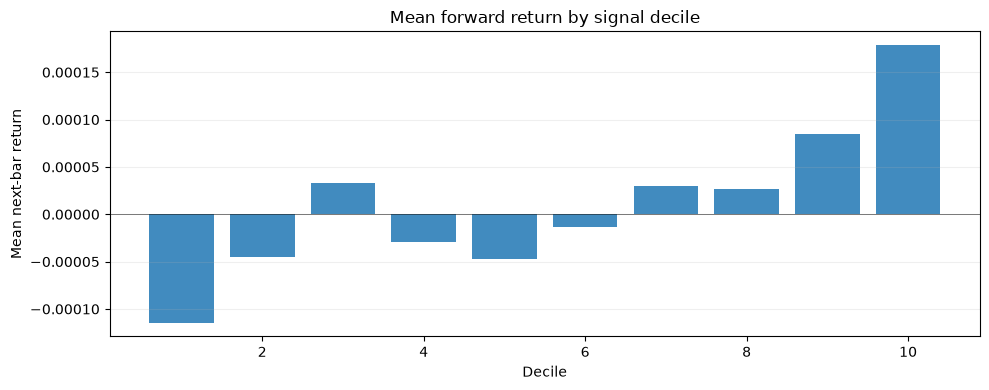

   decile  count  mean_signal  mean_fwd_ret
0       1    833    -0.899769     -0.000114
1       2    833    -0.699315     -0.000045
2       3    833    -0.498780      0.000033
3       4    833    -0.296923     -0.000029
4       5    832    -0.097454     -0.000048
5       6    833     0.102297     -0.000014
6       7    833     0.300391      0.000030
7       8    833     0.500965      0.000027
8       9    833     0.702674      0.000085
9      10    832     0.901294      0.000179


In [5]:
mask = np.isfinite(signal) & np.isfinite(forward_returns)
signal_valid = signal[mask]
returns_valid = forward_returns[mask]

order = np.argsort(signal_valid)
deciles = np.empty(signal_valid.shape[0], dtype=np.int64)
deciles[order] = (np.arange(signal_valid.shape[0]) * 10 // signal_valid.shape[0]) + 1

deciles_df = pd.DataFrame(
    [
        {
            "decile": decile,
            "count": int((decile_mask := deciles == decile).sum()),
            "mean_signal": float(np.nanmean(signal_valid[decile_mask])),
            "mean_fwd_ret": float(np.nanmean(returns_valid[decile_mask])),
        }
        for decile in range(1, 11)
    ]
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(deciles_df["decile"], deciles_df["mean_fwd_ret"], color="tab:blue", alpha=0.85)
ax.axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
ax.set_title("Mean forward return by signal decile")
ax.set_xlabel("Decile")
ax.set_ylabel("Mean next-bar return")
ax.grid(alpha=0.2, axis="y")
fig.tight_layout()
plt.show()

print(deciles_df)

## Next Steps

Note that all of the backtests here are net of transaction costs.

- The metric presented here has high turnover and is most predictive on lower timeframes.
- Market microstructure metrics can be used to enhance directional strategies
  and extend existing signals.
- They can also act as regime filters to help decide when broader
  trend-following ideas are more or less effective.

Register at [Aperiodic.io](https://aperiodic.io) to run an interactive version
of this notebook
with access to all available market microstructure metrics.

